In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [8]:
clientes = pd.read_csv('clientes.csv')

In [9]:
clientes.head()

,ID_Cliente,Nome,Idade,Sexo,Cidade,Estado,Canal_Aquisicao
0,1,Cauã Guerra,56,M,São Paulo,RS,Loja Física
1,2,Luísa Vargas,69,M,Rio de Janeiro,RJ,Online
2,3,Larissa Monteiro,46,M,Porto Alegre,PR,Online
3,4,Larissa Ribeiro,32,F,Porto Alegre,PR,Loja Física
4,5,Otávio Castro,60,M,Belo Horizonte,RJ,Online


In [10]:
# Criar categorias de idade
clientes['Perfil_Idade'] = pd.cut( #pd.cut =faixas
    clientes['Idade'],
    bins=[0, 22, 65, float('inf')], #bins = intervalo
    labels=['Jovem', 'Adulto', 'Idoso'] #labels = nome dos intervalos
)
clientes.head()

,ID_Cliente,Nome,Idade,Sexo,Cidade,Estado,Canal_Aquisicao,Perfil_Idade
0,1,Cauã Guerra,56,M,São Paulo,RS,Loja Física,Adulto
1,2,Luísa Vargas,69,M,Rio de Janeiro,RJ,Online,Idoso
2,3,Larissa Monteiro,46,M,Porto Alegre,PR,Online,Adulto
3,4,Larissa Ribeiro,32,F,Porto Alegre,PR,Loja Física,Adulto
4,5,Otávio Castro,60,M,Belo Horizonte,RJ,Online,Adulto


In [11]:
clientes_dados = clientes.groupby(['Canal_Aquisicao','Perfil_Idade']).size().reset_index(name='Quantidade')
clientes_dados.sort_values(by='Quantidade', ascending=False)

C:\Users\luka1\AppData\Local\Temp\ipykernel_25032\918296013.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  clientes_dados = clientes.groupby(['Canal_Aquisicao','Perfil_Idade']).size().reset_index(name='Quantidade')


,Canal_Aquisicao,Perfil_Idade,Quantidade
4,Online,Adulto,414
1,Loja Física,Adulto,397
3,Online,Jovem,60
5,Online,Idoso,46
0,Loja Física,Jovem,44
2,Loja Física,Idoso,39


A MAIORIA DOS CLIENTES ADULTOS COMPRA TANTO ONLINE (414) QUANTO EM LOJA FÍSICA (397).
JOVENS (<23 ANOS) COMPRAM MAIS ONLINE (60) DO QUE EM LOJA FÍSICA (44).
IDOSOS (>65 ANOS) TAMBÉM PREFEREM ONLINE (46) EM RELAÇÃO À LOJA FÍSICA (39).

In [12]:
media = np.mean(clientes['Idade']) #media= media aritmetica
mediana = np.median(clientes['Idade']) #mediana= valor central
q1 = np.percentile(clientes['Idade'], 25) #q1= primeiro quartil
q2 = np.percentile(clientes['Idade'], 50) #q2= segundo quartil = mediana
q3 = np.percentile(clientes['Idade'], 75) #q3= terceiro quartil
distancia = (media - mediana) / mediana #distancia= distancia entre media e mediana
iqr = q3 - q1 #IQR= intervalo interquartil
limite_inferior = q1 - 1.5 * iqr #Limite inferior para detectar outliers
limite_superior = q3 + 1.5 * iqr #Limite superior para detectar outliers
outliers = clientes['Idade'][(clientes['Idade'] < limite_inferior) | (clientes['Idade'] > limite_superior)] #Detecta outliers #outliers= valores que estão fora do limite inferior e superior
print(f'Primeiro quartil (Q1): {q1}')
print(f'Segundo quartil (Q2): {q2}')
print(f'Terceiro quartil (Q3): {q3}')               
print(f'Média: {media}')
print(f'Mediana:{mediana}')
print(f'Distância: {distancia*100}%')

Primeiro quartil (Q1): 31.0
Segundo quartil (Q2): 44.0
Terceiro quartil (Q3): 56.0
Média: 43.819
Mediana:44.0
Distância: -0.41136363636363044%


A DISTRIBUIÇÃO DE IDADES É QUASE SIMÉTRICA, POIS A MÉDIA (43,8) E A MEDIANA (44) ESTÃO MUITO PRÓXIMAS.  
O IQR DE 25 ANOS MOSTRA QUE 50% (METADE) DOS CLIENTES ESTÃO ENTRE 31 E 56 ANOS, COM POUCA EVIDÊNCIA DE OUTLIERS (ESTÁ DENTRO DA FAIXA)


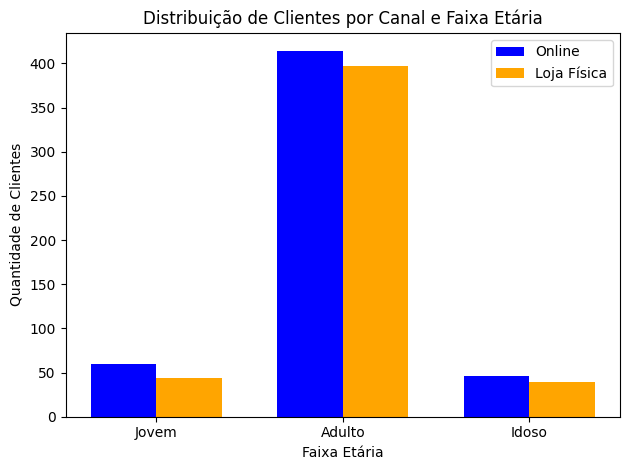

In [13]:
#Gráficos
categorias = ['Jovem', 'Adulto', 'Idoso']
online = [60, 414, 46]
loja_fisica = [44, 397, 39]

x = range(len(categorias))
largura = 0.35

#Gráfico de barras
fig, ax = plt.subplots()
ax.bar([i - largura/2 for i in x], online, width=largura, label='Online', color='blue')
ax.bar([i + largura/2 for i in x], loja_fisica, width=largura, label='Loja Física', color='orange')

# Títulos e legendas
ax.set_xlabel('Faixa Etária')
ax.set_ylabel('Quantidade de Clientes')
ax.set_title('Distribuição de Clientes por Canal e Faixa Etária')
ax.set_xticks(x)
ax.set_xticklabels(categorias)
ax.legend()

# Salvar gráfico
plt.tight_layout()
plt.savefig('grafico_clientes_por_idade_canal.png')
plt.savefig('grafico_clientes_por_idade_canal.pdf')
